In [1]:
import torch
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from collections import defaultdict
from torch.utils.data import DataLoader, Subset

import src.data_cleaning_and_preprocessing._model_ready_dataset as model_ready_dataset
from archive.dataset.tiny_imagenet_dataset import TinyImageNetLoader
from archive.pc_cnn.py_file.pc_5_classify import HierarchicalPCCNN


SEED = 42
BATCH_SIZE = 16

NUM_CLASSES = 20
IMAGES_PER_CLASS = 100

INFERENCE_STEPS = 100

PC_EPOCHS = 10
CLASSIFICATION_EPOCHS = 10

CLASSIFIER_LEARNING_RATE = 0.01

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: mps


In [3]:
cleaned_tiny_imagenet = model_ready_dataset.ModelReadyDatasetLoader(
    TinyImageNetLoader(seed=SEED)
).load()

train_dataset = cleaned_tiny_imagenet[0]
test_dataset = cleaned_tiny_imagenet[1]

In [4]:
selected_classes = list(range(NUM_CLASSES))

class_indices = defaultdict(list)

for i in range(len(train_dataset)):
    _, label = train_dataset[i]
    label = int(label)

    if label in selected_classes:
        class_indices[label].append(i)


generator = torch.Generator()
generator.manual_seed(SEED)

indices = []

for class_id in selected_classes:
    available_indices = class_indices[class_id]

    if len(available_indices) < IMAGES_PER_CLASS:
        raise ValueError(
            f"Class {class_id} has only {len(available_indices)} images, "
            f"but {IMAGES_PER_CLASS} were requested."
        )

    perm = torch.randperm(len(available_indices), generator=generator)[:IMAGES_PER_CLASS]
    selected = [available_indices[i] for i in perm.tolist()]
    indices.extend(selected)


train_subset = Subset(train_dataset, indices)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator
)

print("Total Tiny ImageNet training images:", len(train_dataset))
print("Selected classes:", selected_classes)
print("Number of selected classes:", len(selected_classes))
print("Images per class:", IMAGES_PER_CLASS)
print("Training images:", len(train_subset))
print("Training batches:", len(train_loader))

Total Tiny ImageNet training images: 99953
Selected classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Number of selected classes: 20
Images per class: 100
Training images: 2000
Training batches: 125


In [7]:
test_class_indices = defaultdict(list)

for i in range(len(test_dataset)):
    _, label = test_dataset[i]
    label = int(label)

    if label in selected_classes:
        test_class_indices[label].append(i)


test_generator = torch.Generator()
test_generator.manual_seed(SEED)

test_indices = []

IMAGES_PER_CLASS = 10

for class_id in selected_classes:
    available_indices = test_class_indices[class_id]

    if len(available_indices) < IMAGES_PER_CLASS:
        raise ValueError(
            f"Test class {class_id} has only {len(available_indices)} images, "
            f"but {IMAGES_PER_CLASS} were requested."
        )

    perm = torch.randperm(len(available_indices), generator=test_generator)[:IMAGES_PER_CLASS]
    selected = [available_indices[i] for i in perm.tolist()]
    test_indices.extend(selected)


test_subset = Subset(test_dataset, test_indices)

test_loader = DataLoader(
    test_subset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Total Tiny ImageNet test images:", len(test_dataset))
print("Selected test classes:", selected_classes)
print("Number of selected classes:", len(selected_classes))
print("Images per class:", IMAGES_PER_CLASS)
print("Test images:", len(test_subset))
print("Test batches:", len(test_loader))

Total Tiny ImageNet test images: 9993
Selected test classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Number of selected classes: 20
Images per class: 10
Test images: 200
Test batches: 13


In [8]:
model = HierarchicalPCCNN(
    num_classes=NUM_CLASSES,
    inference_steps=INFERENCE_STEPS
).to(device)

print(model)

HierarchicalPCCNN(
  (level1): ModuleDict(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (deconv): ConvTranspose2d(32, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1), bias=False)
  )
  (level2): ModuleDict(
    (conv): Conv2d(32, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (deconv): ConvTranspose2d(128, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1), bias=False)
  )
  (classifier_pool): AdaptiveAvgPool2d(output_size=(7, 7))
  (classifier): Linear(in_features=6272, out_features=20, bias=True)
)


In [9]:
total_params = sum(p.numel() for p in model.parameters())
autograd_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total unique parameters:", total_params)
print("Autograd-enabled parameters:", autograd_params)

Total unique parameters: 163188
Autograd-enabled parameters: 0


In [10]:
pc_history = []

for epoch in range(PC_EPOCHS):
    total_error_0 = 0.0
    total_error_1 = 0.0
    total_images = 0

    model.train()
    for images, labels in tqdm(train_loader, desc=f"PC-CNN Epoch {epoch + 1}/{PC_EPOCHS}"):
        for image in images:
            result = model(image)

            total_error_0 += result["error_0"]
            total_error_1 += result["error_1"]
            total_images += 1

    mean_error_0 = total_error_0 / total_images
    mean_error_1 = total_error_1 / total_images

    pc_history.append({
        "epoch": epoch + 1,
        "image_error": mean_error_0,
        "r1_error": mean_error_1
    })

    print(
        f"Epoch {epoch + 1}/{PC_EPOCHS} | "
        f"Image Error: {mean_error_0:.6f} | "
        f"r1 Error: {mean_error_1:.6f}"
    )

PC-CNN Epoch 1/10:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/10 | Image Error: 0.047301 | r1 Error: 0.026522


PC-CNN Epoch 2/10:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2/10 | Image Error: 0.028363 | r1 Error: 0.016790


PC-CNN Epoch 3/10:   0%|          | 0/125 [00:00<?, ?it/s]

...

Epoch 8/10 | Image Error: 0.024525 | r1 Error: 0.013966


PC-CNN Epoch 9/10:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 9/10 | Image Error: 0.024512 | r1 Error: 0.013957


PC-CNN Epoch 10/10:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 10/10 | Image Error: 0.024505 | r1 Error: 0.013952


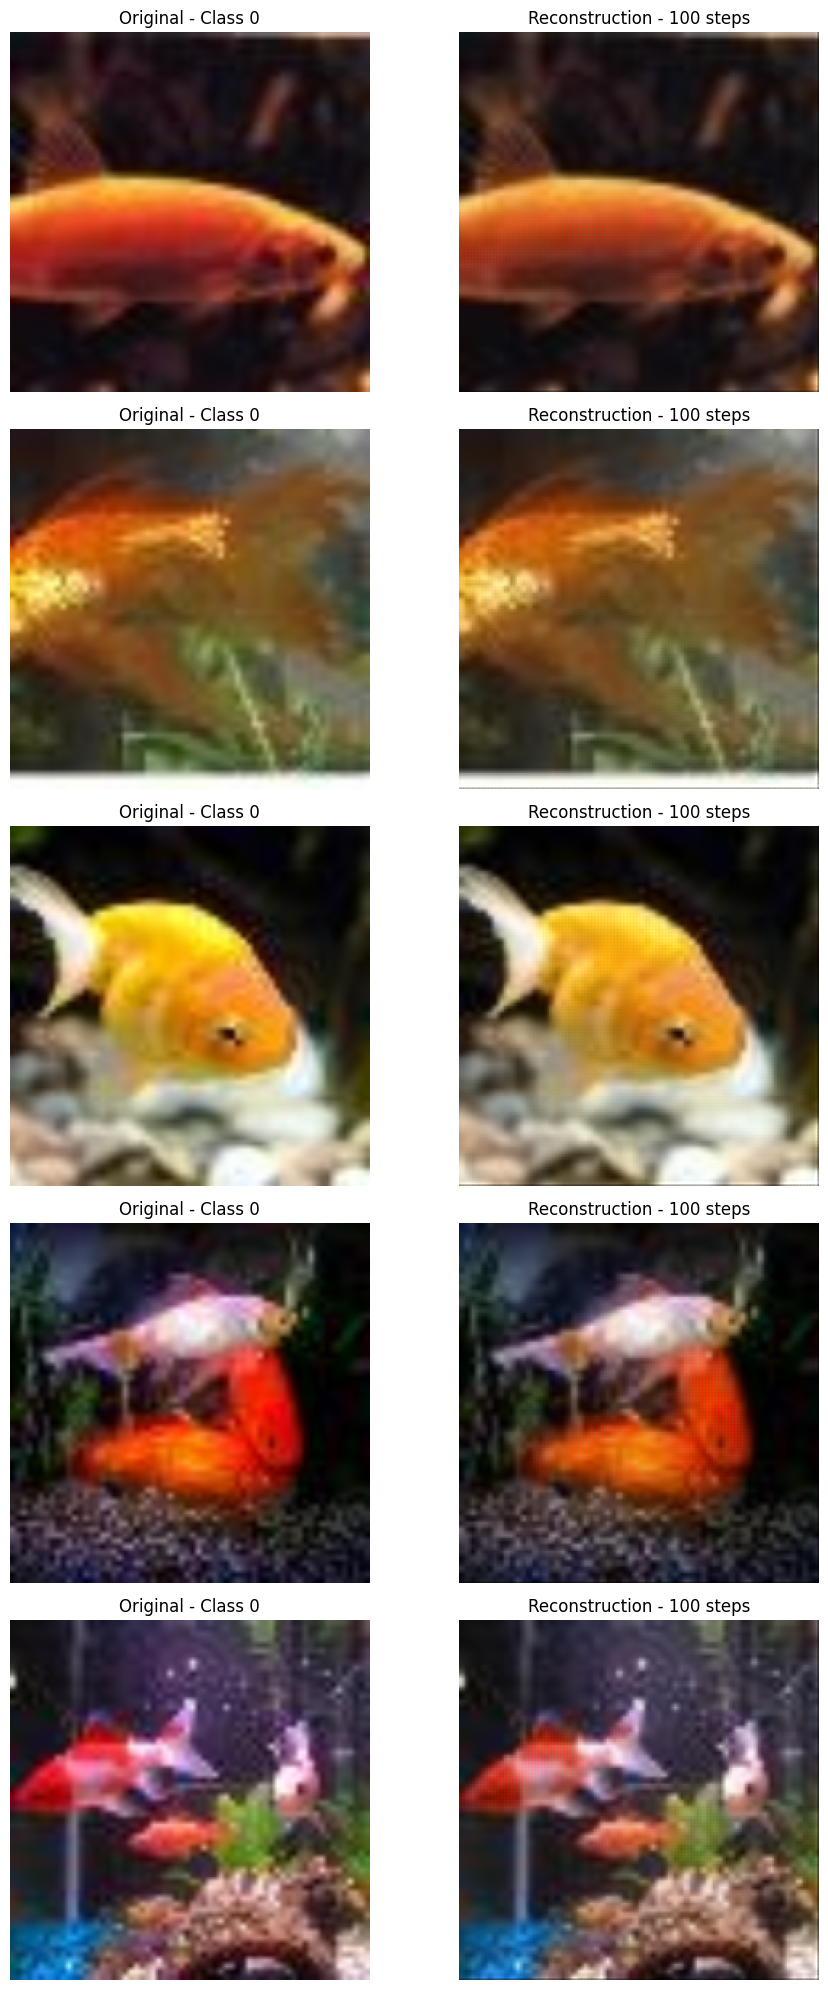

In [11]:
def to_display_image(image):
    image = image.detach().cpu().clamp(0, 1)
    return image.permute(1, 2, 0).numpy()


num_images = 5

fig, axes = plt.subplots(num_images, 2, figsize=(10, num_images * 4))

for i in range(num_images):
    image, label = train_subset[i]

    reconstruction, predicted_r1, reconstruction_r2, r2, steps, converged = model.reconstruct(image)

    axes[i, 0].imshow(to_display_image(image))
    axes[i, 0].set_title(f"Original - Class {label}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(to_display_image(reconstruction))
    axes[i, 1].set_title(f"Reconstruction - {steps} steps")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [12]:
@torch.no_grad()
def train_classifier(model, train_loader, device, learning_rate):
    total_loss = 0.0
    total_correct = 0
    total_images = 0

    model.train()
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        loss, correct, batch_size = model.update_classifier(
            images,
            labels,
            learning_rate=learning_rate
        )

        total_loss += loss * batch_size
        total_correct += correct
        total_images += batch_size

    mean_loss = total_loss / total_images
    accuracy = 100.0 * total_correct / total_images

    return mean_loss, accuracy

In [13]:
@torch.no_grad()
def test_classifier(model, test_loader, device):
    total_loss = 0.0
    total_correct = 0
    total_images = 0

    model.eval()
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model.classify(images)

        probabilities = torch.softmax(logits, dim=1)

        true_probabilities = probabilities[
            torch.arange(labels.shape[0], device=labels.device),
            labels
        ]

        loss = -torch.log(true_probabilities + 1e-8).mean().item()

        predictions = logits.argmax(dim=1)

        total_loss += loss * labels.shape[0]
        total_correct += (predictions == labels).sum().item()
        total_images += labels.shape[0]

    mean_loss = total_loss / total_images
    accuracy = 100.0 * total_correct / total_images

    return mean_loss, accuracy

In [14]:
classification_history = []

best_val_accuracy = -1.0
best_classifier_weight = None
best_classifier_bias = None

for epoch in tqdm(range(CLASSIFICATION_EPOCHS), desc="Local Classification Training"):

    train_loss, train_accuracy = train_classifier(
        model,
        train_loader,
        device,
        CLASSIFIER_LEARNING_RATE
    )

    val_loss, val_accuracy = test_classifier(
        model,
        test_loader,
        device
    )

    classification_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy
    })

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_classifier_weight = model.classifier.weight.detach().cpu().clone()
        best_classifier_bias = model.classifier.bias.detach().cpu().clone()

    print(
        f"Epoch {epoch + 1}/{CLASSIFICATION_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.2f}%"
    )

Local Classification Training:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 2.9419 | Train Accuracy: 10.25% | Val Loss: 2.8703 | Val Accuracy: 14.00%
Epoch 2/10 | Train Loss: 2.8514 | Train Accuracy: 15.40% | Val Loss: 2.8065 | Val Accuracy: 17.00%
Epoch 3/10 | Train Loss: 2.7961 | Train Accuracy: 16.70% | Val Loss: 2.7662 | Val Accuracy: 20.50%
Epoch 4/10 | Train Loss: 2.7578 | Train Accuracy: 18.95% | Val Loss: 2.7319 | Val Accuracy: 21.50%
Epoch 5/10 | Train Loss: 2.7261 | Train Accuracy: 19.65% | Val Loss: 2.7069 | Val Accuracy: 23.50%
Epoch 6/10 | Train Loss: 2.7009 | Train Accuracy: 19.50% | Val Loss: 2.6863 | Val Accuracy: 22.00%
Epoch 7/10 | Train Loss: 2.6786 | Train Accuracy: 21.30% | Val Loss: 2.6734 | Val Accuracy: 22.00%
Epoch 8/10 | Train Loss: 2.6596 | Train Accuracy: 22.20% | Val Loss: 2.6586 | Val Accuracy: 22.50%
Epoch 9/10 | Train Loss: 2.6435 | Train Accuracy: 21.95% | Val Loss: 2.6442 | Val Accuracy: 22.00%
Epoch 10/10 | Train Loss: 2.6275 | Train Accuracy: 22.85% | Val Loss: 2.6367 | Val Accuracy: 23.00%


In [15]:
with torch.no_grad():
    model.classifier.weight.copy_(best_classifier_weight.to(device))
    model.classifier.bias.copy_(best_classifier_bias.to(device))

print("Best Validation Accuracy:", best_val_accuracy)

Best Validation Accuracy: 23.5


In [16]:
for name, param in model.named_parameters():
    print(name, param.requires_grad)

level1.conv.weight False
level2.conv.weight False
classifier.weight False
classifier.bias False


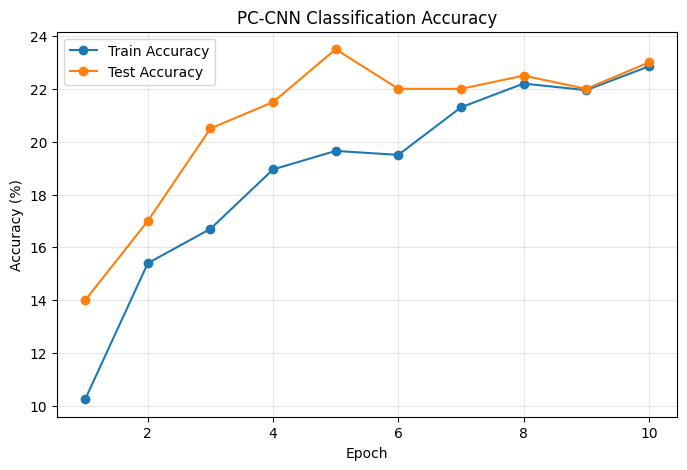

In [17]:
epochs_plot = [item["epoch"] for item in classification_history]
train_accuracy_plot = [item["train_accuracy"] for item in classification_history]
test_accuracy_plot = [item["val_accuracy"] for item in classification_history]

plt.figure(figsize=(8, 5))

plt.plot(epochs_plot, train_accuracy_plot, marker="o", label="Train Accuracy")
plt.plot(epochs_plot, test_accuracy_plot, marker="o", label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("PC-CNN Classification Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

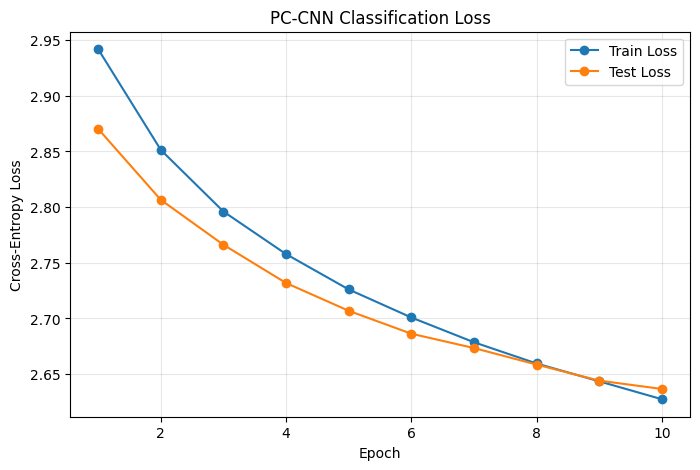

In [18]:
train_loss_plot = [item["train_loss"] for item in classification_history]
test_loss_plot = [item["val_loss"] for item in classification_history]

plt.figure(figsize=(8, 5))

plt.plot(epochs_plot, train_loss_plot, marker="o", label="Train Loss")
plt.plot(epochs_plot, test_loss_plot, marker="o", label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("PC-CNN Classification Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()